# Step 3: Calculate and Prepare Metrics


This notebook walks through the metric workflow outputs used by the rest of Spatial-VTK. You will resolve metric settings from the config, write a task preview, create a long metrics table, and export dashboard-ready files.


## Imports

These helpers resolve metric settings and write standard downstream metric outputs.


In [1]:
from spatial_vtk.config.notebook import notebook_timer, register_svtk_cell_timer

with notebook_timer():
    from IPython.display import display
    from spatial_vtk.config import SpatialVTKConfig
    from spatial_vtk.config.metrics import metric_settings_summary, metrics_settings_from_config
    from spatial_vtk.io import read_config_table, load_output_table, write_output_table
    from spatial_vtk.metrics.workflow import summarize_metric_tasks, write_metric_outputs
    from spatial_vtk.metrics.plot import plot_band_score_distribution, plot_residuals_vs_distance, plot_score_trends
    from spatial_vtk.spatial.map import plot_station_metric_map
    register_svtk_cell_timer()

Run time: 38.84 s


## Configuration

Load the config, then choose a small set of metrics and transforms for this tutorial run.


In [2]:
from pathlib import Path

# Use the repository root so paths match the public source checkout.
repo_root = Path.cwd()
config_path = repo_root / "data/examples/configuration/example_spatial_vtk_config.yaml"

# Load the tutorial run scenario and make it the active config for later package calls.
cfg = SpatialVTKConfig.from_file(config_path, run_scenario="tutorial").activate()

notebook_overrides = {
    "groups": ["amplitude", "spectral"],
    "transforms": ["log2_residual", "anderson_2004_gof"],
    "output_mode": "full",
}

Run time: 22.2 ms


## Resolve the Metric Settings

The config file provides the defaults. The override above narrows the tutorial to amplitude and spectral metrics.


In [3]:
# Resolve the metric plan from the active config plus the small notebook override.
metric_settings = metrics_settings_from_config(overrides=notebook_overrides)

# Display the metric settings with human-readable labels.
metric_settings_summary(metric_settings)

,Setting,Value
0,Groups,"amplitude, spectral"
1,Metrics,"PGA, PGV, PGD, PSA, FAS"
2,Transforms,"log2(observed / synthetic), Anderson 2004 GOF"
3,Components,"Z, R, T"
4,Passbands,"1-2 sec, 2-3 sec"
5,Output mode,full
6,Spectral periods,"1 s, 2 s, 3 s, 5 s"
7,Synthetic max frequency,1 Hz


Run time: 29.5 ms


## Write a Task Preview

A full run would create one task per event, station, component, model, passband, and metric set. This preview shows the kind of task table you can batch locally or submit on SLURM.


In [4]:
# Read the example metric snapshot from the configured input path.
metric_snapshot = read_config_table("paths.metric_snapshot")

# Build the complete task table from the unique event, station, component, model, and passband combinations.
metric_tasks = metric_snapshot[["event_id", "station", "component", "model", "band"]].drop_duplicates().copy()
metric_tasks["metrics"] = ", ".join(metric_settings.metrics)
metric_tasks["transforms"] = ", ".join(metric_settings.transforms)
metric_tasks["output_mode"] = metric_settings.output_mode
metric_tasks["use_qc"] = True

# Estimate the number of tasks and rough resources needed for this metric run.
task_estimate = summarize_metric_tasks(
    metric_tasks,
    seconds_per_task=60.0,
    memory_gb_per_task=2.0,
    cpus_per_task=1,
    parallel_tasks=4,
)

# Save the full task table so a larger run can be launched in batches or on a cluster.
write_output_table("metric_tasks", metric_tasks)

# Show the resource estimate, then preview the first few tasks.
display(task_estimate)
metric_tasks.head(12)

,Estimate,Value,Notes
0,Metric tasks,20,One task is one event-station-component-model-...
1,Approximate metric evaluations,100,Task count multiplied by the requested metrics...
2,Unique events,5,
3,Unique stations,5,
4,Components,"R, T, Z",
5,Models,cvmsi,
6,Passbands,"1-2 sec, 2-3 sec, 3-5 sec","Period-band labels, for example 1-2 sec."
7,Approximate CPU-hours,0.33,Uses 60 seconds/task and 1 CPU/task.
8,Memory per task,2 GB,Planning estimate; benchmark a small batch for...
9,Wall time at 4 parallel tasks,5.0 min,Approximate elapsed time if every task takes t...


,event_id,station,component,model,band,metrics,transforms,output_mode,use_qc
0,ci38038071,BFS,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
1,ci38038071,BHP,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
2,ci38695658,BLC,R,cvmsi,2-3 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
3,ci39812319,BRE,T,cvmsi,3-5 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
4,ci38695658,CAC,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
5,ci39812319,BHP,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
6,ci39756418,BLC,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
7,ci40699207,BRE,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
8,ci38695658,BFS,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True
9,ci39812319,CAC,Z,cvmsi,1-2 sec,"PGA, PGV, PGD, PSA, FAS","log2_residual, anderson_2004_gof",full,True


Run time: 105.2 ms


## Write Standard Metric Outputs

The long metrics table keeps observed values, synthetic values, residuals, scores, and metadata in one row-oriented format.


In [5]:
# Read prepared station metadata for metric enrichment.
stations = load_output_table("prepared_stations")

# Read prepared event metadata for metric enrichment.
events = load_output_table("prepared_events")

# Write the standard long metrics, path summary, and dashboard-ready metric outputs.
write_metric_outputs(
    metric_snapshot,
    events=events,
    stations=stations,
    residual_column="log2_residual",
    score_column="anderson_2004_gof",
    table_format="parquet",
)

# Read the long metrics table written by the workflow helper.
metrics_long = load_output_table("metrics_long")

# Save the enriched metrics table used by the spatial and mapping notebooks.
write_output_table("metrics_enriched", metrics_long)
metrics_long.head()

,event_id,station,network,component,model,band,metric,metric_group,period_s,value_obs,...,strike,dip,rake,usgs_url,observed_pickle,event_json,synthetic_mseed,selected_station_count,overlapping_broadband_station_count,event_count
0,ci38038071,BFS,CI,Z,cvmsi,1-2 sec,PGA,amplitude,NaN,0.118,...,312.0,79.0,178.0,https://earthquake.usgs.gov/earthquakes/eventp...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/synth...,30,52,4.0
1,ci38038071,BHP,CI,Z,cvmsi,1-2 sec,PGV,amplitude,NaN,5.410,...,312.0,79.0,178.0,https://earthquake.usgs.gov/earthquakes/eventp...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/synth...,30,52,5.0
2,ci38695658,BLC,CI,R,cvmsi,2-3 sec,PSA,spectral,2.0,0.284,...,96.0,48.0,108.0,https://earthquake.usgs.gov/earthquakes/eventp...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/synth...,30,75,4.0
3,ci39812319,BRE,CI,T,cvmsi,3-5 sec,FAS,spectral,3.0,0.037,...,122.0,85.0,179.0,https://earthquake.usgs.gov/earthquakes/eventp...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/synth...,30,77,5.0
4,ci38695658,CAC,CI,Z,cvmsi,1-2 sec,PGA,amplitude,NaN,0.096,...,96.0,48.0,108.0,https://earthquake.usgs.gov/earthquakes/eventp...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/obser...,data/examples/la_basin_five_event_subset/synth...,30,75,NaN


Run time: 5.75 s


## Make Metric Diagnostic Figures

These figures use a larger QC-passed metrics table so the trends are easier to inspect than they would be with the tiny task-preview snapshot. The distance plots use LOWESS fits so the trend lines stay flexible without forcing a straight-line relationship.

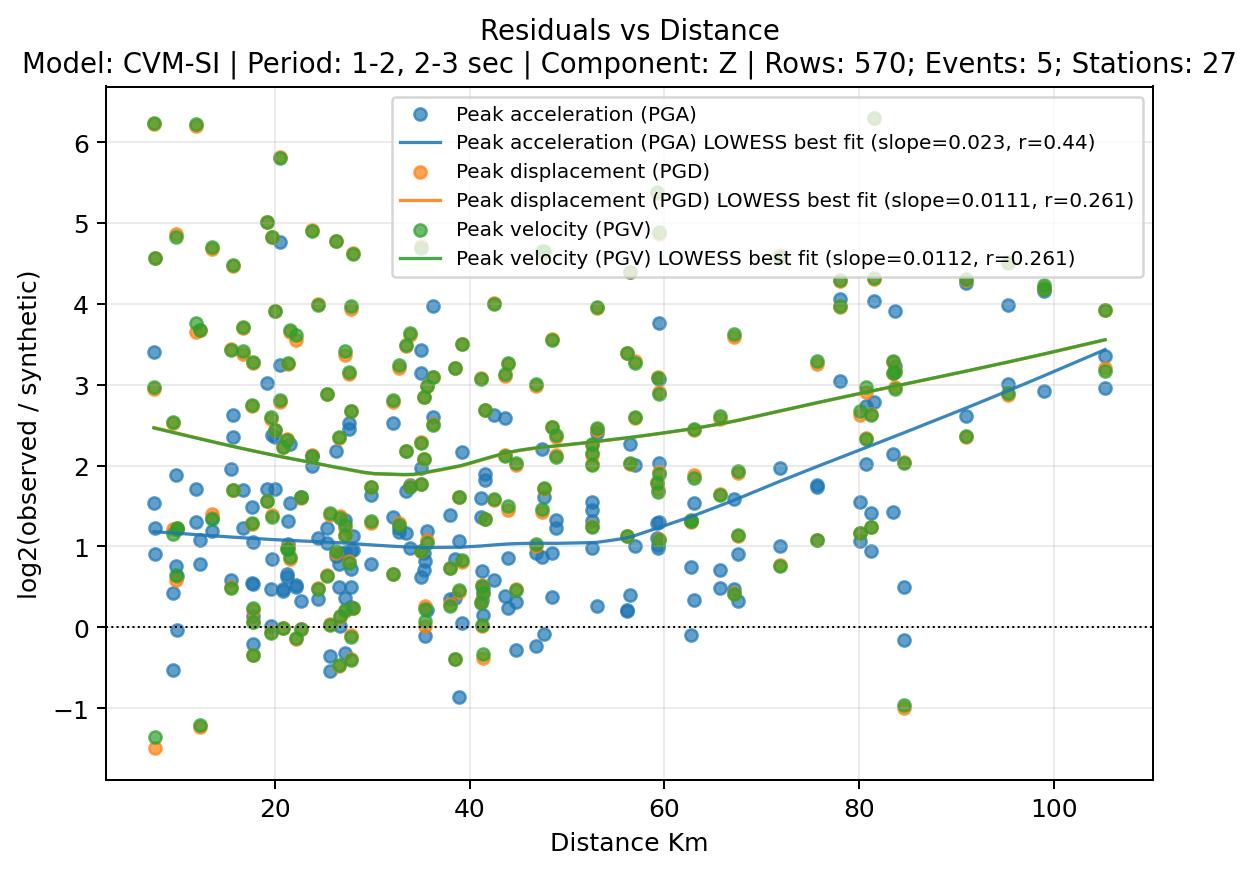

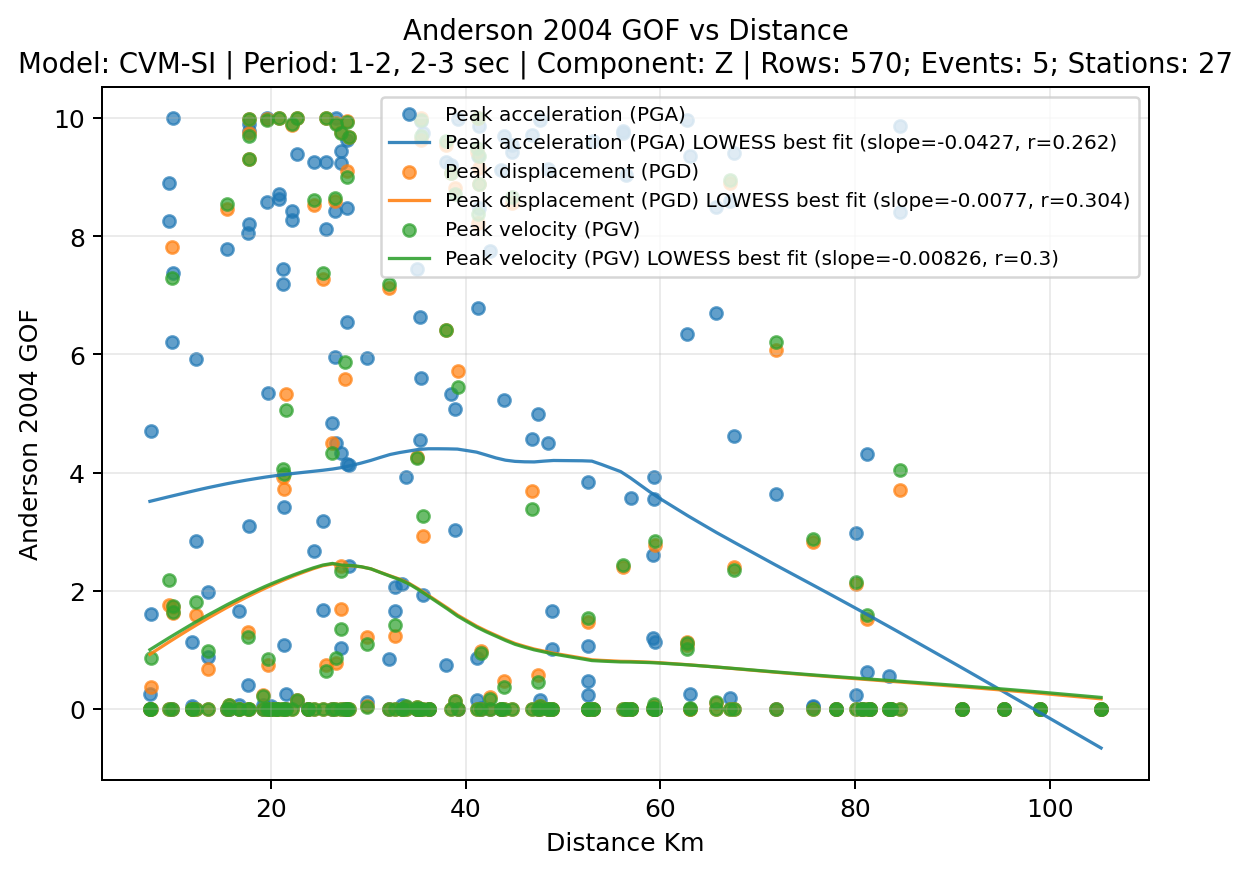

Run time: 1.61 s


In [6]:
# Load the larger QC-passed metric table for plotting examples.
figure_metrics = read_config_table("paths.metric_figure_snapshot")

# Keep these example figures focused on metrics with enough rows to show clear trends.
figure_metrics = figure_metrics.loc[figure_metrics["metric"].isin(["PGA", "PGV", "PGD"])].copy()

# Plot residuals against source-to-station distance with a LOWESS fit for each metric.
distance_fig = plot_residuals_vs_distance(
    figure_metrics,
    y_col="log2_residual",
    group_col="metric",
    fit="lowess",
    connect_points=False,
    title="Residuals vs Distance",
    showfig=True,
    savefig=True,
)

# Plot GOF scores against distance with a LOWESS fit for each metric.
score_fig = plot_score_trends(
    figure_metrics,
    score_col="anderson_2004_gof",
    group_col="metric",
    fit="lowess",
    connect_points=False,
    title="Anderson 2004 GOF vs Distance",
    showfig=True,
    savefig=True,
)

## Map Station Residuals

A station map is a useful first look at whether residuals are spatially organized. Here, each station is colored by its mean PGA log2 residual.

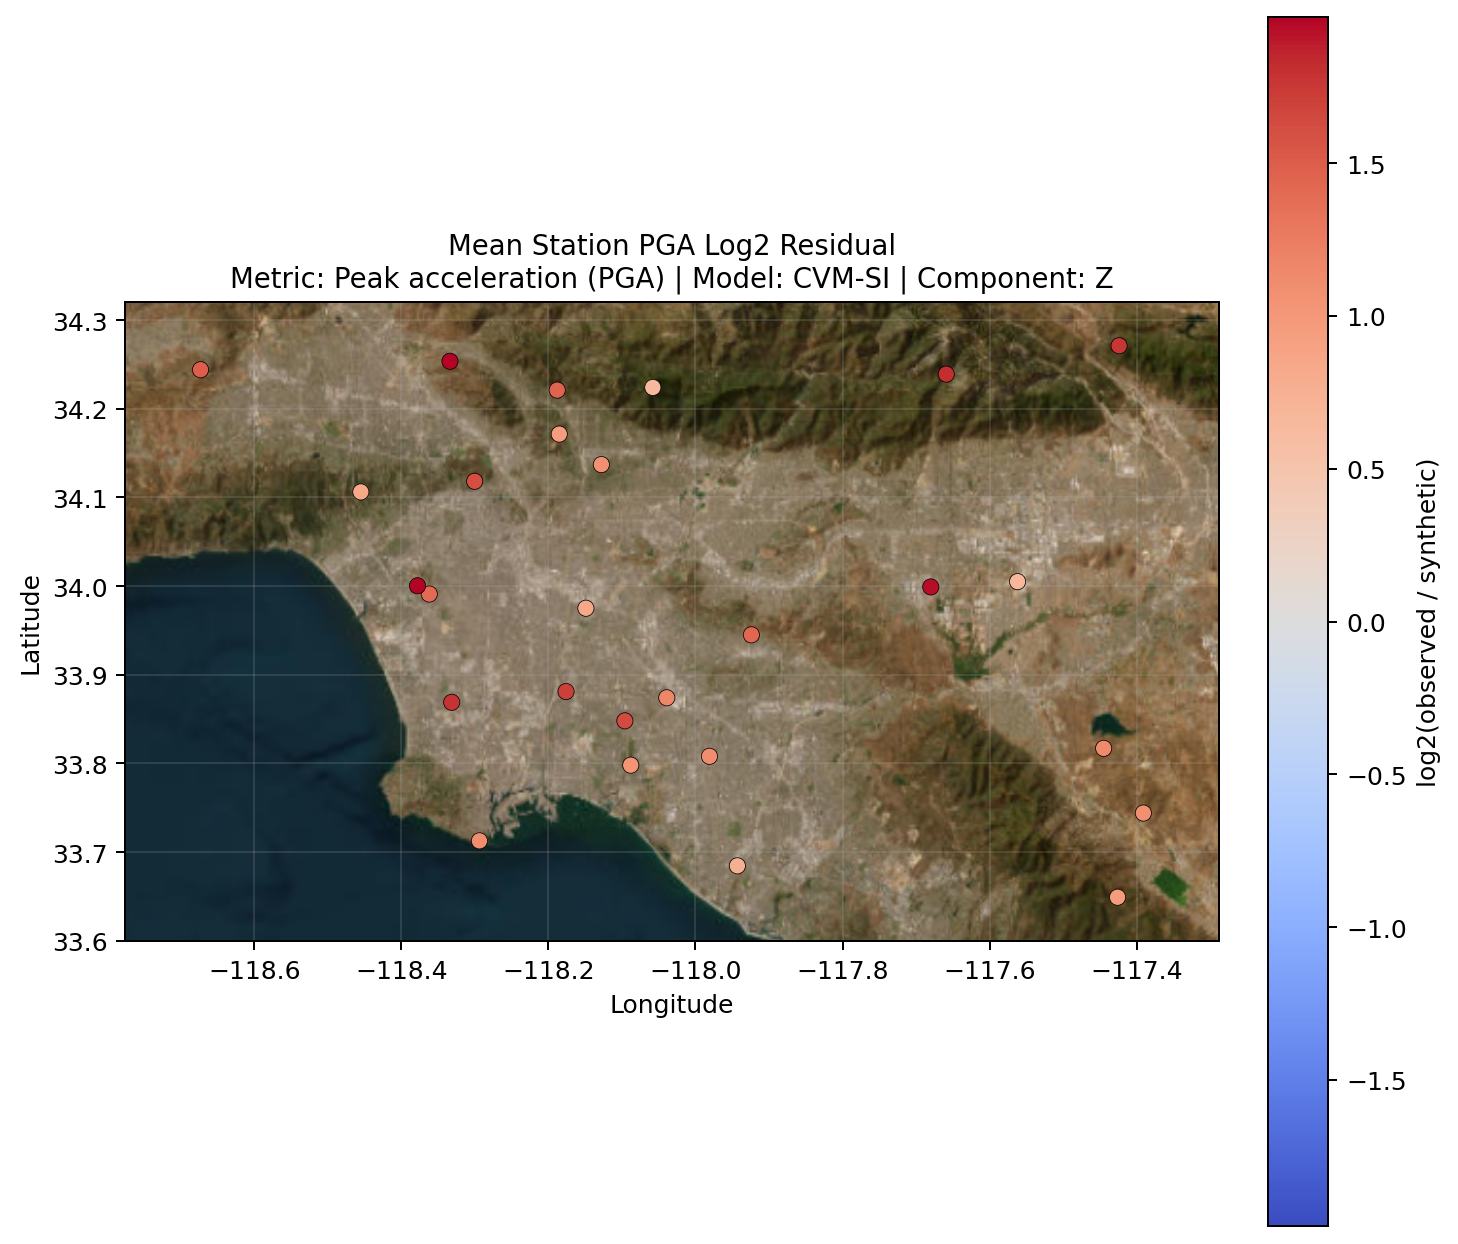

Run time: 2.70 s


In [7]:
# Average PGA residuals by station so each station appears once on the map.
station_pga = (
    figure_metrics.loc[figure_metrics["metric"].eq("PGA")]
    .groupby(["station", "sta_lat", "sta_lon", "model", "component", "metric"], dropna=False, as_index=False)["log2_residual"]
    .mean()
)

# Map mean station residuals with a basemap for geographic context.
station_metric_fig = plot_station_metric_map(
    station_pga,
    value_col="log2_residual",
    title="Mean Station PGA Log2 Residual",
    showfig=True,
    savefig=True,
)

## Compare Residuals by Period Band

This distribution groups log2 residuals by period band and metric so you can quickly see whether residual behavior changes across the requested bands.

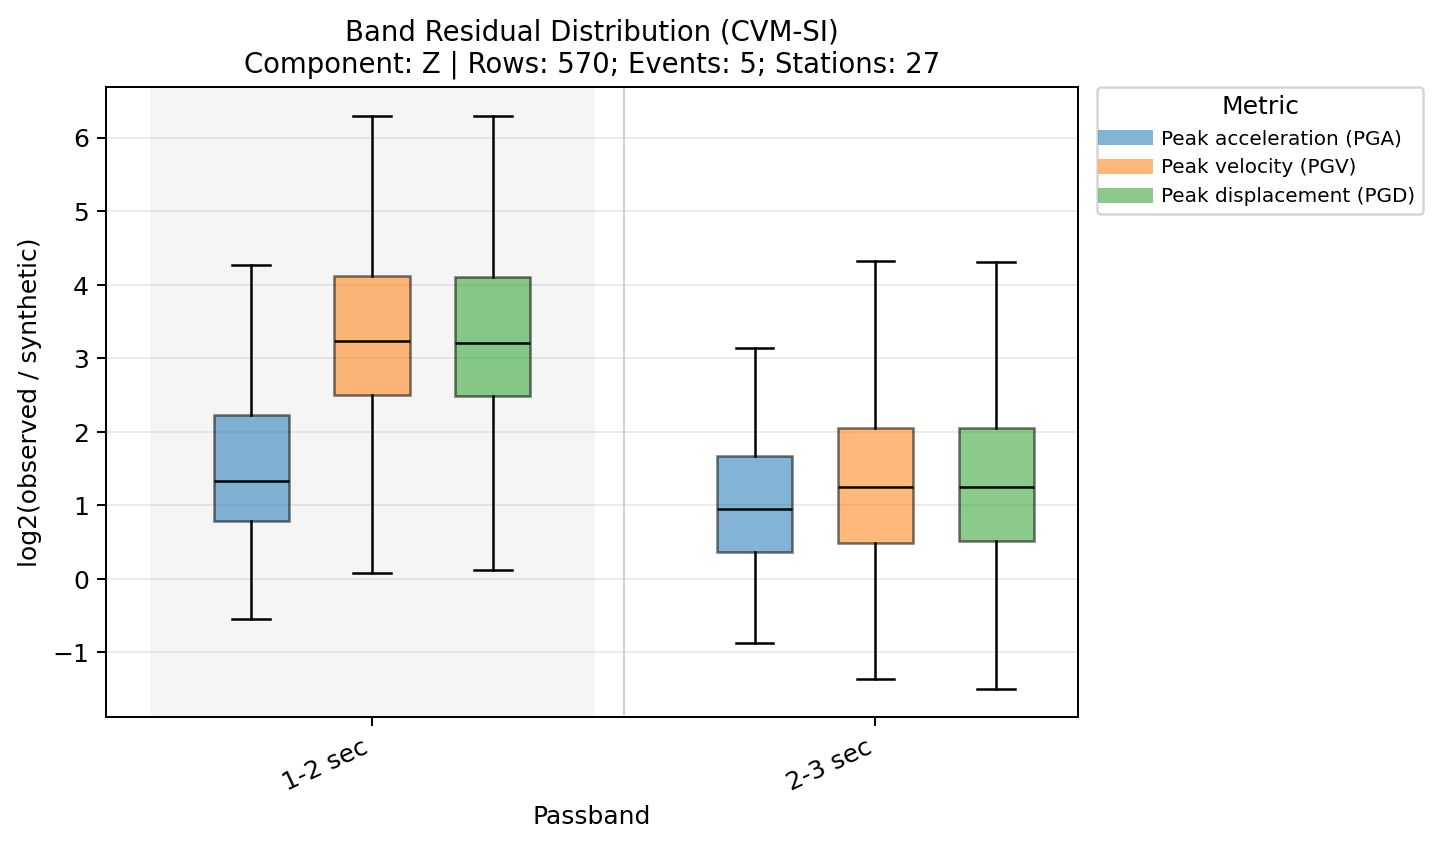

Run time: 428.0 ms


In [8]:
# Compare log2 residual distributions across period bands for the same metric set.
band_residual_fig = plot_band_score_distribution(
    figure_metrics,
    band_col="band",
    score_col="log2_residual",
    color_col="metric",
    title="Band Residual Distribution (CVM-SI)",
    showfig=True,
    savefig=True,
)